# 5. The transfer-matrix spectrum: block power method, the entanglement barrier, and the wall

Even with the validated VD2 MPO, the transverse contraction stops converging beyond a certain time. This notebook investigates why by looking directly at the spectrum of the spatial transfer matrix $\mathcal{E}$.

Some of the findings are:
1. The method using single-vector deflation for the subleading eigenvalue fails (gives NaN and Infs), so we use a block power method (well-behaved at degeneracy).
2. The gap closes. Two leading eigenvalues approach each other while $|\lambda_0|$ stays flat => manifestation of the entanglement barrier. The gap closes faster for the NNN model. The leading eigenvalue traced in the complex plane lies on a circle (emergent dual unitarity).
3. Past the conformal window, the single-vector entropy breaks at the gap closing (transverse contraction limitation).
4. Appendix: We show why our quench to the critical point is not a DQPT.

> **Note (UV regulator):** All spectral data computed here comes from the converged **$n_\beta=4$** master block-PM which uses the $\beta_0=0.2$ cooling required for a clean conformal boundary state.
> Without the UV regulator, there is no conformal boundary.

In [ ]:
include("../src/thesislib.jl")
using JLD2, LsqFit, Printf, Plots
gr()

# Load already computed points
cachefile = "../results/data/nb8_master.jld2"
isfile(cachefile) || error("Missing $cachefile. Run notebook 7 first")
d = load(cachefile, "done")

# helper functions 
ok(p,T) = haskey(d,(p,T)) && haskey(d[(p,T)], :theta)
Ts(p)   = sort([k[2] for k in keys(d) if k[1]==p && ok(p,k[2])])

# phase handling
ph(t) = angle(-t)
unwrap(v) = (o=copy(v); for i in 2:length(v); while o[i]-o[i-1]> pi; o[i]-=2pi; end;
                                            while o[i]-o[i-1]<-pi; o[i]+=2pi; end; end; o)  # unwrap a vector of phases to be continuous
dphw(a,b) = mod(ph(a)-ph(b)+pi, 2pi) - pi   # phase diff between two complex numbers, in [-π,π]

# track the physical λ0 by modulus continuity
function track_lambda0(p)
    lam = ComplexF64[]
    pm = nothing    # tracker
    for T in Ts(p)
        th = d[(p,T)].theta
        i  = pm === nothing ? 1 : argmin(abs.(abs.(th) .- pm))
        push!(lam, th[i])
        pm = abs(th[i])
    end
    Ts(p), lam
end

println("master sweep loaded:  p=0 → ", length(Ts(0.0)), " pts,  p=0.1 → ", length(Ts(0.1)),
        " pts   (T=2..12, nbeta=4)")

master sweep loaded:  p=0 → 11 pts,  p=0.1 → 11 pts   (T=2..12, nbeta=4)


## Why we need the block power method

The power method converges at a rate set by the gap ratio $|\lambda_1|/ \lambda_0|$ between the two leading transfer-matrix eigenvalues: as it approaches $1$, the PM finds it harder to converge to a well-defined vector.

One way to measure $\lambda_1$ is by deflation: iterate in the subspace orthogonal to the dominant pair $(\langle L_0|,|R_0\rangle)$, projecting it out at every step with the bilinear (non-conjugating) overlap. But deflation divides by the dominant eigenvalue and relies on the bi-orthogonal pair staying well separated. Precisely at the gap closing (where $|\lambda_1|\to|\lambda_0|$), the residual after projection collapses to (near) zero norm, so normalizing it produces `NaN`/`Inf`, which crashes the simulation. 

Another solution is to use the block power method (`block_transfer_eigs`): an oblique Rayleigh-Ritz (Petrov-Galerkin) subspace iteration that extracts the leading $k$ eigenvalues at once and never divides by a single dominant one. Each iteration it keeps $k$ right tMPS $|R_j\rangle$ and $k$ left $\langle L_i|$ (random complex seeds), applies $\mathcal{E}$ (for the left part, it is the pure transpose), builds the two $k\times k$ non-conjugating pencils $S_{ij}=\langle L_i|R_j\rangle$, $M_{ij}=\langle L_i|\mathcal{E}|R_j\rangle$, solves $W=\mathrm{pinv}(S)\,M$ then `eigen(W)`, and refreshes any collapsed direction when $\mathrm{cond}(S)$ spikes.

In [ ]:
pd = 0.1
Td = 3.0
nbd = 4

mpo, scaffold = build_alcaraz_tmpo(Td; p=pd, lambda=1.0, dt=0.1, nbeta=nbd, MPO_alg="VD2")
theta, L, R, info = block_transfer_eigs(mpo, scaffold; k=4, maxdim=64, maxdims=collect(2:2:64),
    cutoff=1e-12, cutoffs=[fill(1e-8,40); 1e-10], itermax=3000, eps_conv=1e-6,
    trunc_mode=:rtm, n_track=2, stuck_after=400)
    
@printf("live   p=%.1f T=%.0f  |θ| = %s   (%d iters, %s)\n", pd, Td,
        join([@sprintf("%.4f",abs(t)) for t in theta], ", "), info[:niters], info[:reason])
@printf("cache  p=%.1f T=%.0f  |θ| = %s   ⇒ the live run reproduces the master sweep\n", pd, Td,
        join([@sprintf("%.4f",abs(t)) for t in d[(pd,Td)].theta], ", "))

┌ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:82
┌ Warning: Tensor *not* symmetric (dim=2|id=874|"S=1/2,Site") <-> (dim=2|id=874|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
┌ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:84
┌ Warning: Tensor *not* symmetric (dim=7|id=153|"Link,l=1") <-> (dim=7|id=433|"Link,l=2"), normdiff = 1.1566412865695994
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
┌ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:82
┌ Warning: Tensor *not* symmet

live   p=0.1 T=3  |θ| = 1.5529, 1.5192, 1.3858, 1.3424   (461 iters, stuck)
cache  p=0.1 T=3  |θ| = 1.5529, 1.5192, 1.3858, 1.3424   ⇒ the live run reproduces the master sweep


┌ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/tmpo/fw_tmpo_blocks.jl:84
┌ Warning: Tensor *not* symmetric (dim=7|id=318|"Link,l=1") <-> (dim=7|id=446|"Link,l=2"), normdiff = 1.4350175351861996
└ @ ITransverse /home/jmarquezol/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93


## The gap closes

With the block method we trace the leading eigenvalues cleanly through the degeneracy. One subtlety: the transfer-matrix spectrum comes in **± pairs** — the physical $\lambda_0$ and its "$-\lambda_0$ partner", which sit $\approx\pi$ apart in phase at nearly equal modulus. The naive ratio of the two largest moduli $|\theta_2|/|\theta_1|$ then measures the *splitting within that pair*, not a gap between distinct states, so it spuriously peaks at $T\approx6$ and dips afterwards. (We checked this dip is **not** a truncation artifact: the bilinear **RTM** and the Hermitian **RDM** truncations of `block_transfer_eigs` agree on it to 4 digits.)

The **physical gap** divides the next *distinct* eigenvalue $\lambda_1$ by the physical $\lambda_0$, skipping the partner (reusing the cache's `i0`/`ip` indices from nb7's `pick_phys`). It closes **monotonically toward $1$**, and closes much faster for the NNN model than for Ising (the NNN frustration scrambles the state more quickly). The entanglement barrier is present in both.

In [ ]:
# Gap ratio |λ₁|/|λ₀|.  The transfer-matrix spectrum comes in ± pairs (the physical λ₀ and its
# −λ₀ partner, ≈π apart in phase at nearly equal modulus), so the naive |θ[2]|/|θ[1]| measures the
# SPLITTING WITHIN that pair, not a gap between distinct states — hence its spurious peak-then-dip
# at T≈6.  The PHYSICAL gap skips the partner: λ₁ = the next DISTINCT eigenvalue, over the physical
# λ₀.  We reuse the cache's own physical/partner indices (i0, ip) written by nb7's pick_phys.
function gapratio(p; physical=true)
    times  = Ts(p)
    ratios = Float64[]
    for T in times
        e  = d[(p,T)]; th = e.theta
        if physical
            i0 = haskey(e, :i0) ? e.i0 : 1                      # physical λ₀
            ip = haskey(e, :ip) ? e.ip : 2                      # its −λ₀ partner
            others = [j for j in eachindex(th) if j != i0 && j != ip]
            lam0 = abs(th[i0])
            lam1 = isempty(others) ? 0.0 : maximum(abs(th[j]) for j in others)
        else
            lam0 = abs(th[1]); lam1 = abs(th[2])                # raw top-two moduli (mixes in the partner)
        end
        push!(ratios, lam0 < 1e-30 ? 0.0 : lam1 / lam0)
    end
    return (times, ratios)
end

times_ising,   gap_ising     = gapratio(0.0)
times_alcaraz, gap_alcaraz   = gapratio(0.1)
_,             naive_alcaraz = gapratio(0.1; physical=false)    # exposes the spurious dip

pltg = plot(
    times_ising, gap_ising;
    label="p=0  (Ising, integrable)",
    marker=:circle, lw=2.5, color=:blue, xlabel="T", ylabel="physical gap  |λ₁|/|λ₀|",
    framestyle=:box, grid=true, legend=:bottomright,
    title="Transfer-matrix gap closes FASTER for frustrated Alcaraz (p=0.1)"
)
plot!(pltg, times_alcaraz, gap_alcaraz;
    label="p=0.1  (Alcaraz, NNN-frustrated)", marker=:square, lw=2.5, color=:red)
# the naive top-two-moduli ratio for p=0.1: peaks then DIPS because it includes the −λ₀ partner
plot!(pltg, times_alcaraz, naive_alcaraz;
    label="p=0.1  naive |θ₂|/|θ₁| (incl. −λ₀ partner)",
    ls=:dot, lw=1.5, color=:red, alpha=0.5, marker=:x, ms=3)
hline!(pltg, [1.0]; ls=:dash, color=:gray, label="gap closed")

mkpath("../results/imgs")
savefig(pltg, "../results/imgs/block_pm_ising_vs_alcaraz.png")

pltg


## Is the dip a truncation artifact? RTM vs RDM

The dip could be blamed on the **RTM** truncation, whose non-Hermitian SVD of the transition matrix $|R\rangle\langle L|$ is ill-conditioned at a degeneracy. To rule that out, `block_transfer_eigs` also offers the **RDM** truncation (`trunc_mode=:rdm`) — the Hermitian per-vector reduced density matrix $|v\rangle\langle v^*|$, the block analogue of `powermethod_lr`'s `alg="densitymatrix"`, which is a *positive* (stable) eigenproblem. We recompute the leading spectrum with both, from the same random seed.

In the conformal window ($T\le8$) RTM and RDM agree on the eigenvalue moduli to ~4 digits (`max|Δ|θ||` ≈ $10^{-3}$), so the dip is **not** a truncation artifact — it is the $-\lambda_0$ partner discussed above. Tellingly, RDM *converges* (hits `eps_conv`) where RTM only gets *stuck*: the Hermitian route is genuinely better conditioned, yet it lands on the same eigenvalues — confirming the eigenVALUES are robust even though the convergence behaviour (and the eigenVECTORS, hence the entropy) are not.

**The wall ($T\gtrsim10$) is a different regime, and a stabler truncation does *not* rescue it.** There the block PM no longer converges (it always finishes `stuck`), and the leading eigenvalues themselves become *seed-dependent*: a cold start at $T=10$ can return a spurious $|\theta_0|\!\sim\!2$ where the warm-started ladder gives $\sim\!1.55$. So the wall-wiggle is a non-convergence / selection effect — RDM converges faster but cannot manufacture convergence at a genuine near-degeneracy where the eigenVECTORS are intrinsically ill-conditioned (the limitation analysed in the next sections). We therefore restrict the RTM/RDM check to the pre-wall window above.

In [ ]:
# ── RTM vs RDM truncation: is the dip / wall-wiggle a truncation artifact? ──
# block_transfer_eigs truncates each de-mixed Ritz pair two ways (trunc_mode kwarg):
#   :rtm — bilinear transition matrix |R⟩⟨L|  (block analogue of powermethod_lr alg="RTM");
#          optimal for ⟨L|R⟩ but a NON-Hermitian SVD, ill-conditioned at the degeneracy
#   :rdm — Hermitian per-vector RDM |v⟩⟨v*|    (block analogue of alg="densitymatrix");
#          drops the L–R coupling but a POSITIVE Hermitian eigenproblem → stable
# We compare the leading spectrum from BOTH (same random seed) at several T. Set regen=true to
# (re)compute missing points — EXPENSIVE: each block solve is minutes (RTM) to ~1 h (RDM) per T.
using Random
cmpf  = "../results/data/nb5_rtm_vs_rdm.jld2"
regen = false
cmp   = isfile(cmpf) ? load(cmpf, "done") : Dict{Tuple{Float64,Symbol},Any}()
if regen
    for T in [6.0, 8.0, 10.0, 11.0, 12.0], mode in (:rtm, :rdm)
        haskey(cmp, (T,mode)) && continue
        Random.seed!(20260627)                          # identical seed for both modes at each T
        mpo, sc = build_alcaraz_tmpo(T; p=0.1, lambda=1.0, dt=0.1, nbeta=4, MPO_alg="VD2")
        th, _, _, inf = block_transfer_eigs(mpo, sc; k=4, maxdim=64, maxdims=collect(2:2:64),
            cutoff=1e-12, cutoffs=[fill(1e-8,40); 1e-10], itermax=1200, eps_conv=1e-6,
            trunc_mode=mode, n_track=2, stuck_after=200)
        cmp[(T,mode)] = (theta=th, gap=abs(th[2])/abs(th[1]), niters=inf[:niters], reason=inf[:reason])
        jldsave(cmpf; done=cmp)
    end
end

Tcmp = sort(unique(T for (T,m) in keys(cmp)))
@printf("%-5s | %-9s %-9s | %-16s %-16s | %s\n",
        "T", "RTM gap", "RDM gap", "RTM reason@it", "RDM reason@it", "max|Δ|θ||")
for T in Tcmp
    (haskey(cmp,(T,:rtm)) && haskey(cmp,(T,:rdm))) || continue
    a = cmp[(T,:rtm)]; b = cmp[(T,:rdm)]
    dth = maximum(abs.(sort(abs.(a.theta)) .- sort(abs.(b.theta))))   # eigenvalue-modulus agreement
    @printf("%-5.0f | %-9.5f %-9.5f | %-16s %-16s | %.1e\n",
            T, a.gap, b.gap, "$(a.reason)@$(a.niters)", "$(b.reason)@$(b.niters)", dth)
end


## gap closing = entanglement barrier + emergent dual unitarity

A closing gap with a flat leading modulus (regular Loschmidt echo) is another manifestation of entanglement barrier, but this time in the spectrum of the transfer matrix.

In the complex plane, the physical $\lambda_0(T)$ (leading eigenvalue) sits on a near-constant-radius arc with a winding phase (emergent dual unitarity, for both $p$).

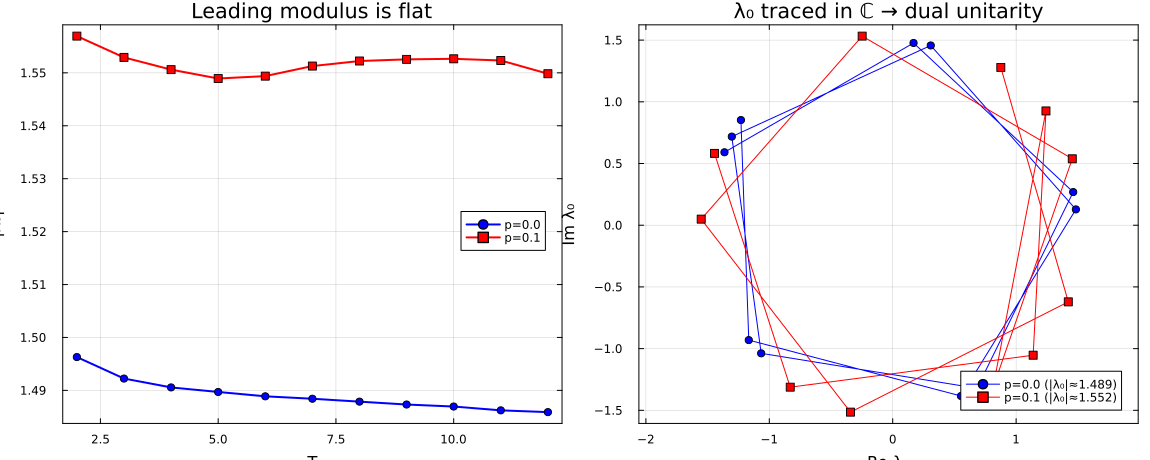

In [ ]:
plt = plot(layout=(1,2), size=(1150,460))
for (p, c, mk) in [(0.0, :blue, :circle), (0.1, :red, :square)]
    Tg, lam = track_lambda0(p)

    plot!(plt, Tg, abs.(lam); subplot=1, marker=mk, lw=2, color=c, label="p=$p",
          xlabel="T", ylabel="|λ₀|", title="Leading modulus is flat", framestyle=:box, legend=:right)

    rbar = sum(abs, lam)/length(lam)
    plot!(plt, real.(lam), imag.(lam); subplot=2, marker=mk, ms=4, lw=1, color=c,
          label="p=$p (|λ₀|≈$(round(rbar,digits=3)))", xlabel="Re λ₀", ylabel="Im λ₀",
          title="λ₀ traced in ℂ → dual unitarity", framestyle=:box, aspect_ratio=:equal, legend=:bottomright)
end

mkpath("../results/imgs"); savefig(plt, "../results/imgs/alcaraz_gap_dualunitarity.png"); plt

## There is still a wall (where the method's reach ends)

If we look at the entropies: the physical-$\lambda_0$ Rényi-2 dome (see notebook 7) is conformal (peak $\sim0.3$, growing logarithmically with $T$) for $p=0.1$ up to $T=8$, but it breaks at $T=10$. The single-vector entropy breaks at the gap closing.

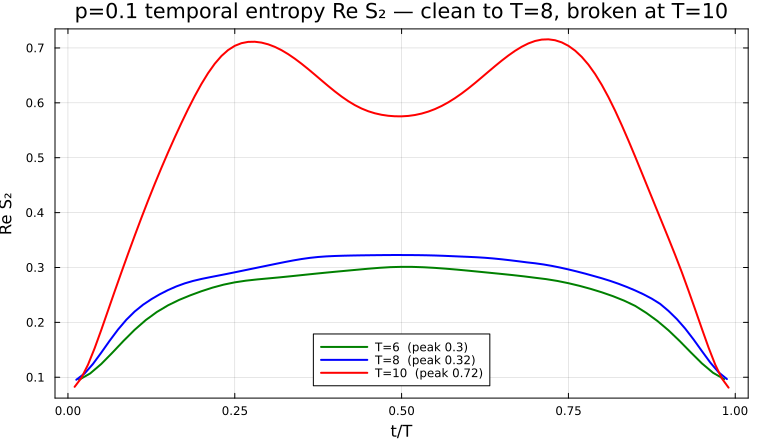

In [ ]:
plt = plot(size=(760,440), framestyle=:box, legend=:bottom,
           title="p=0.1 temporal entropy Re S₂ — clean to T=8, broken at T=10",
           xlabel="t/T", ylabel="Re S₂")

for (T, c) in [(6.0, :green), (8.0, :blue), (10.0, :red)]
    haskey(d,(0.1,T)) || continue
    re = real.(d[(0.1,T)].s2_phys)
    x = (1:length(re)) ./ (length(re)+1)
    plot!(plt, x, re; color=c, lw=2, label="T=$(Int(T))  (peak $(round(maximum(re),digits=2)))")
end

mkpath("../results/imgs"); savefig(plt, "../results/imgs/gap_closing_wall.png"); plt

Near a degeneracy, the eigenvectors are ill-conditioned: a perturbation of size $\varepsilon$ rotates the "physical" vector within the near-degenerate plane by $\sim\varepsilon/\text{gap}$. At gap $=10^{-3}$ that is a $10^3\times$ amplification. This is fundamental linear algebra, not a power-method bug.

Summary of what we tried:

| attempt | idea | result |
|---|---|---|
| physical-$\lambda_0$ selection (nb7) | pick the block vector at the continued eigenvalue | clean to $T\le9$, **breaks at $T=10$** |
| subspace projector $P=\sum_i\|R_i\rangle\langle L_i\|$ | gauge-invariant, mix the degenerate cluster | **inflates** — peak $0.28\!\to\!0.76\,(m{=}2)\to1.16\,(m{=}3)$: the rank-$m$ projector adds *classical mixing entropy*, the wrong (mixed) observable |
| pure-state continuity | project the previous-$T$ physical vector onto the current block | **drifts** — $0.26\!\to\!0.34\!\to\!0.86$ across $T{=}4,5,6$: the block vectors are themselves contaminated |

A direct finite-$L$ forward contraction converges to the fixed point only at rate $(\lambda_1/\lambda_0)^L$, so at gap $\approx0.999$ one would need $L\gtrsim10^4$. The ill-conditioned eigenvector is intrinsic to the dual-unitarity regime.

### Does the eigenvalue route rescue $c$ past the wall?

Since the eigenVALUES are well-conditioned, the natural hope is to extract $c$ from them alone — **Eq.(3)**
$\mathrm{Im}(\lambda_0)/T = a_0 + \kappa/T^2$ with $c\propto|\kappa|$, calibrated by the $p{=}0$ standard.
We test it on the full $T=2\ldots12$ grid.

In [ ]:
dt = 0.1
v = 2.0
function eq3_kappa(p; Tmin)
    _, lam = track_lambda0(p)
    y = unwrap([ph(l) for l in lam]) ./ Ts(p)
    m = Ts(p) .>= Tmin
    A = hcat(ones(sum(m)), 1.0 ./ Ts(p)[m].^2)
    (A \ y[m])[2]
end

# |λ0| smoothness: clean (monotone) for p=0, NON-monotone for p=0.1 (the selection ambiguity)
for p in [0.0, 0.1]
    _, lam = track_lambda0(p)
    println("p=$p  |λ0|: ", join([@sprintf("%.4f", abs(l)) for l in lam], " "))
end

@printf("\nEq.(3) calibrated c(p=0.1)=0.5·|κ(0.1)/κ(0)| vs fit window:\n  %-7s %-10s %-10s %-8s\n",
        "Tmin","κ(p=0)","κ(p=0.1)","c_cal")
for Tmin in [2.0,3.0,4.0,5.0,6.0]
    k0 = eq3_kappa(0.0; Tmin=Tmin)
    k1 = eq3_kappa(0.1; Tmin=Tmin)
    @printf("  T≥%-4.0f %-10.3f %-10.3f %-8.3f\n", Tmin, k0, k1, 0.5*abs(k1/k0))
end

p=0.0  |λ0|: 1.4963 1.4922 1.4906 1.4897 1.4889 1.4884 1.4879 1.4873 1.4869 1.4862 1.4859
p=0.1  |λ0|: 1.5569 1.5529 1.5506 1.5489 1.5494 1.5513 1.5522 1.5525 1.5527 1.5523 1.5498

Eq.(3) calibrated c(p=0.1)=0.5·|κ(0.1)/κ(0)| vs fit window:
  Tmin    κ(p=0)     κ(p=0.1)   c_cal   
  T≥2    -5.400     -3.725     0.345   
  T≥3    -7.573     -3.579     0.236   
  T≥4    -9.446     -3.278     0.174   
  T≥5    -11.086    -6.604     0.298   
  T≥6    -12.543    -24.493    0.976   


**The eigenvalue route is *also* contaminated for $p=0.1$.** For $p=0$ (well-separated spectrum) the
tracked $|\lambda_0|$ is smooth and monotone and Eq.(3) is reasonably behaved. For $p=0.1$ the tracked
$|\lambda_0|$ is **non-monotone** (it dips then rises): three eigenvalues sit at $|\theta|\approx1.55$, so
*selecting which one is the physical $\lambda_0$* is itself ambiguous at the near-degeneracy. The calibrated
$c$ then swings between $0.17$ and $0.98$ with the fit window — not a usable number. So the same degeneracy
that destroys the eigenVECTOR (entropy) also corrupts the eigenVALUE *selection*. The eigenvalue route is
robust only for the well-separated $p=0$ case (and, for Ising, in the *symmetric* formulation C-T use).

## The robust result before the "wall"

The trustworthy central charge comes from the pre-wall conformal window, not from anything past it. The clean-window Rényi-2 slope (notebook 7, $T=4\!-\!9$, calibrated against $p{=}0$) gives

$$\,c(p{=}0.1)\;=\;0.47\pm0.05\,$$

consistent with the Ising $1/2$. This shows that temporal Ising universality survives NNN frustration at $p=0.1$ (already proved with DMRG, nb4).

The reasons why NNN model does not reach higher T (compared to Ising):
1. Symmetry. Ising's Murg MPO is left–right symmetric ($\langle L|=|R^*\rangle$), so C-T use the
   symmetric RTM diagonalization (Autonne–Takagi), which a complex-symmetric eigenproblem, far better
   conditioned near a degeneracy. Alcaraz's MPO is asymmetric (upper-triangular FSM), forcing the
   non-symmetric power method whose eigenvectors blow up at the degeneracy.
2. The NNN coupling closes the transfer gap faster, so the barrier (and the wall)
   arrive at lower $T$.


The reach of the transverse method for the NNN model here is therefore bounded.

---
## Appendix — About DQPTs

At first we thought the closing gap was a non-analytic Loschmidt rate, but here we show why our
quench is **not** a DQPT. The Loschmidt amplitude $\mathcal{L}(t)=\langle\Psi_0|e^{-iHt}|\Psi_0\rangle$ is a
boundary partition function with complex "inverse temperature" $it$; its rate function
$\ell(t)=-\tfrac1N\log|\mathcal{L}(t)|^2$ can develop non-analytic kinks at times $t_n^*$ when Fisher
zeros cross the time axis (Heyl et al., 2013).

For the transverse-field Ising model this is exact: a quench from $g_0$ to $g_1$ produces kinks at
$t_n^* = (n+\tfrac12)\,\pi/\varepsilon_{k^*}(g_1)$ only if the quench crosses $g_c=1$, where
$\cos k^* = (1+g_0g_1)/(g_0+g_1)$ and $\varepsilon_k(g)=2\sqrt{1+g^2-2g\cos k}$. 

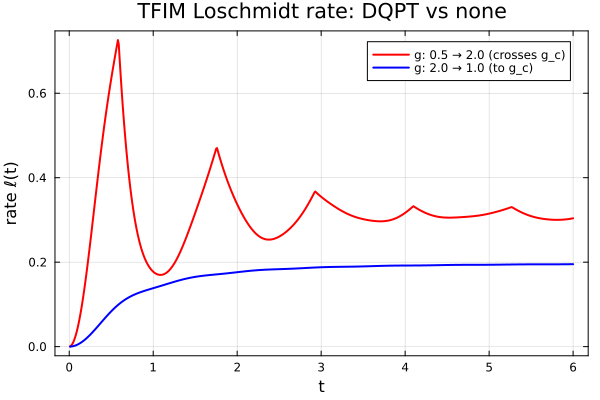

In [7]:
# Exact free-fermion TFIM Loschmidt rate (Heyl et al. 2013) — instant, no MPS.
εk(k,g)  = 2*sqrt(1 + g^2 - 2g*cos(k))
θk(k,g)  = 0.5*atan(sin(k), g - cos(k))                # Bogoliubov angle
function tfim_rate(ts, g0, g1; nk=4000)
    ks = range(0, pi, length=nk); dk = step(ks)
    [ -(1/pi)*sum(log(max(1 - sin(2*(θk(k,g0)-θk(k,g1)))^2 * sin(εk(k,g1)*t)^2, 1e-300)) for k in ks)*dk
      for t in ts ]
end

ts = range(0.01, 6.0, length=600)
cross  = tfim_rate(ts, 0.5, 2.0)   # quench ACROSS g_c=1  → DQPT kinks
tocrit = tfim_rate(ts, 2.0, 1.0)   # quench TO g_c=1       → no finite-time DQPT
plot(ts, cross;  label="g: 0.5 → 2.0 (crosses g_c)", lw=2, color=:red, xlabel="t",
     ylabel="rate ℓ(t)", framestyle=:box, grid=true, title="TFIM Loschmidt rate: DQPT vs none")
plot!(ts, tocrit; label="g: 2.0 → 1.0 (to g_c)", lw=2, color=:blue)

### Why our quench has no DQPT

The red curve is the textbook DQPT: sharp kinks for a quench that **crosses** the critical point. The blue
curve — a quench **to** the critical point — is smooth: as $g_1\to g_c=1$ the critical mode moves to
$k^*\to0$ where $\varepsilon_{k^*}\to0$ and the first DQPT time $t_1^*\to\infty$. The Fisher zero becomes
*marginal* and never crosses the time axis at finite time.

This is exactly our situation: we always quench the ANNNI-type model **to** its critical point $\lambda=1$,
never across it, so **no DQPT occurs at finite time**, for $p=0$ or $p>0$. The closing transfer-matrix gap
diagnosed above is therefore the universal **entanglement barrier**, not a dynamical phase transition.